In [3]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, Input
import warnings
warnings.filterwarnings('ignore')

# Veriyi otomatik indir
path = kagglehub.dataset_download("hassan06/nslkdd")
print("Dataset path:", path)

# Sütun isimleri
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

# Dosya yollarını bul ve yükle
import os
files = os.listdir(path)
print("Bulunan dosyalar:", files)

train_path = os.path.join(path, 'KDDTrain+.txt')
test_path  = os.path.join(path, 'KDDTest+.txt')

train_df = pd.read_csv(train_path, names=columns)
test_df  = pd.read_csv(test_path,  names=columns)

print("Train shape:", train_df.shape)
print("Test shape:",  test_df.shape)
train_df.head()

Using Colab cache for faster access to the 'nslkdd' dataset.
Dataset path: /kaggle/input/nslkdd
Bulunan dosyalar: ['KDDTest+.arff', 'KDDTest-21.arff', 'KDDTest1.jpg', 'KDDTrain+.txt', 'KDDTrain+_20Percent.txt', 'KDDTest-21.txt', 'KDDTest+.txt', 'KDDTrain+.arff', 'index.html', 'nsl-kdd', 'KDDTrain+_20Percent.arff', 'KDDTrain1.jpg']
Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
train_df = train_df.drop('difficulty', axis=1)
test_df  = test_df.drop('difficulty', axis=1)

cat_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in cat_cols:
    combined = pd.concat([train_df[col], test_df[col]])
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

train_df['label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label']  = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values
X_test  = test_df.drop('label', axis=1).values
y_test  = test_df['label'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("Saldırı oranı (train):", y_train.mean().round(3))
print("Saldırı oranı (test):",  y_test.mean().round(3))

X_train shape: (125973, 41)
X_test shape: (22544, 41)
Saldırı oranı (train): 0.465
Saldırı oranı (test): 0.569


In [5]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

n_features = X_train.shape[1]  # 41

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_features, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\n CNN eğitimi tamamlandı!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 39, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,481 (642.50 KB)

 Trainable params: 164,481 (642.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9537 - loss: 0.1390 - val_accuracy: 0.9881 - val_loss: 0.0343
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9872 - loss: 0.0354 - val_accuracy: 0.9906 - val_loss: 0.0265
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9883 - loss: 0.0305 - val_accuracy: 0.9923 - val_loss: 0.0239
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9910 - loss: 0.0251 - val_accuracy: 0.9930 - val_loss: 0.0218
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9910 - loss: 0.0248 - val_accuracy: 0.9933 - val_loss: 0.0178
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.9918 - loss: 0.0221 - val_accuracy: 0.9926 - val_loss: 0.0183
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9919 - loss: 0.0216 - val_accuracy: 0.9943 - val_loss: 0.0170
Epoch 8/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9931 - loss: 0.0189 - 

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,769 (14.72 KB)

 Trainable params: 3,769 (14.72 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9767 - val_loss: 0.6899
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6891 - val_loss: 0.6755
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6547 - val_loss: 0.6718
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8266 - val_loss: 0.6706
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7092 - val_loss: 0.6686
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6884 - val_loss: 0.6680
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7606 - val_loss: 0.6676
Epoch 8/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7494 - val_loss: 0.6673
Epoch 9/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6966 - val_loss: 0.6664
Epoch 10/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6981 - val_loss: 0.6662
Epoch 11/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7568 - val_loss: 0.6661
Epoch 12/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

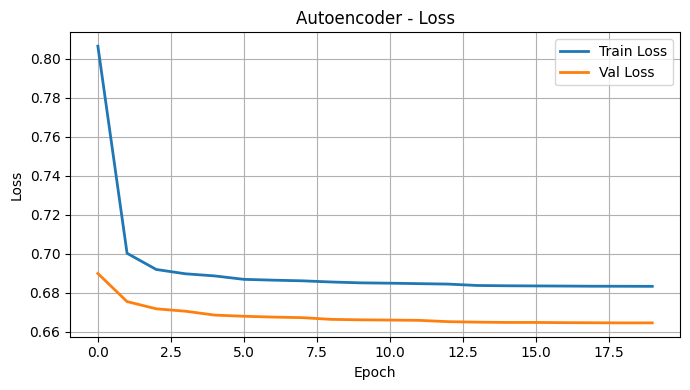

In [6]:
# AUTOENCODER
encoding_dim = 16

input_layer = Input(shape=(41,))

# Encoder
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(41, activation='sigmoid')(decoded)

# Modeller
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Eğitim
ae_history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\n Autoencoder eğitimi tamamlandı!")

# Autoencoder Loss Grafiği
plt.figure(figsize=(7, 4))
plt.plot(ae_history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(ae_history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Autoencoder - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ae_loss.png', dpi=150)
plt.show()

In [7]:
# Encoder ile özellik çıkar (41 → 16 boyut)
X_train_encoded = encoder.predict(X_train)
X_test_encoded  = encoder.predict(X_test)

# CNN için reshape (16 → (16, 1))
X_train_ae_cnn = X_train_encoded.reshape(X_train_encoded.shape[0], X_train_encoded.shape[1], 1)
X_test_ae_cnn  = X_test_encoded.reshape(X_test_encoded.shape[0], X_test_encoded.shape[1], 1)

print("AE çıktı shape:", X_train_ae_cnn.shape)

# AE-CNN Modeli
ae_cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(16, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

ae_cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ae_cnn_model.summary()

# Eğitim
ae_cnn_history = ae_cnn_model.fit(
    X_train_ae_cnn, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\n AE-CNN eğitimi tamamlandı!")

3937/3937 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
AE çıktı shape: (125973, 16, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 14, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,049 (258.00 KB)

 Trainable params: 66,049 (258.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9348 - loss: 0.1694 - val_accuracy: 0.9822 - val_loss: 0.0516
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9821 - loss: 0.0531 - val_accuracy: 0.9885 - val_loss: 0.0354
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9851 - loss: 0.0424 - val_accuracy: 0.9871 - val_loss: 0.0374
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9875 - loss: 0.0360 - val_accuracy: 0.9910 - val_loss: 0.0274
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9883 - loss: 0.0328 - val_accuracy: 0.9904 - val_loss: 0.0272
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9891 - loss: 0.0310 - val_accuracy: 0.9924 - val_loss: 0.0231
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9897 - loss: 0.0288 - val_accuracy: 0.9913 - val_loss: 0.0241
Epoch 8/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9893 - loss: 0.0296 - val_accu

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
         CNN MODEL SONUÇLARI
              precision    recall  f1-score   support

      Normal       0.64      0.94      0.76      9711
     Saldırı       0.93      0.60      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.77      0.75     22544
weighted avg       0.81      0.75      0.75     22544

       AE-CNN MODEL SONUÇLARI
              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79      9711
     Saldırı       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544



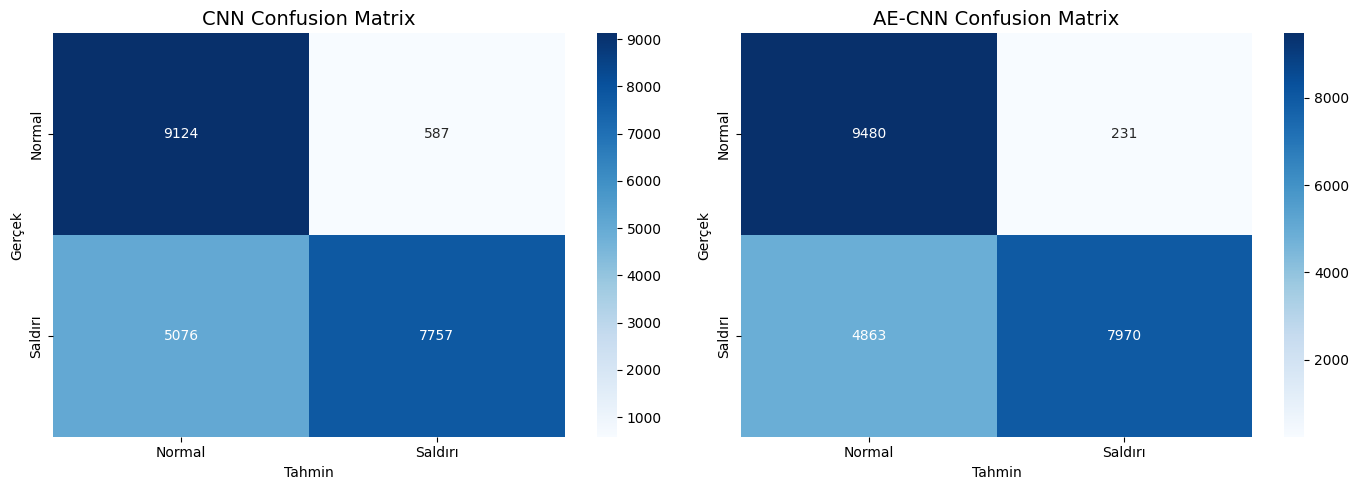

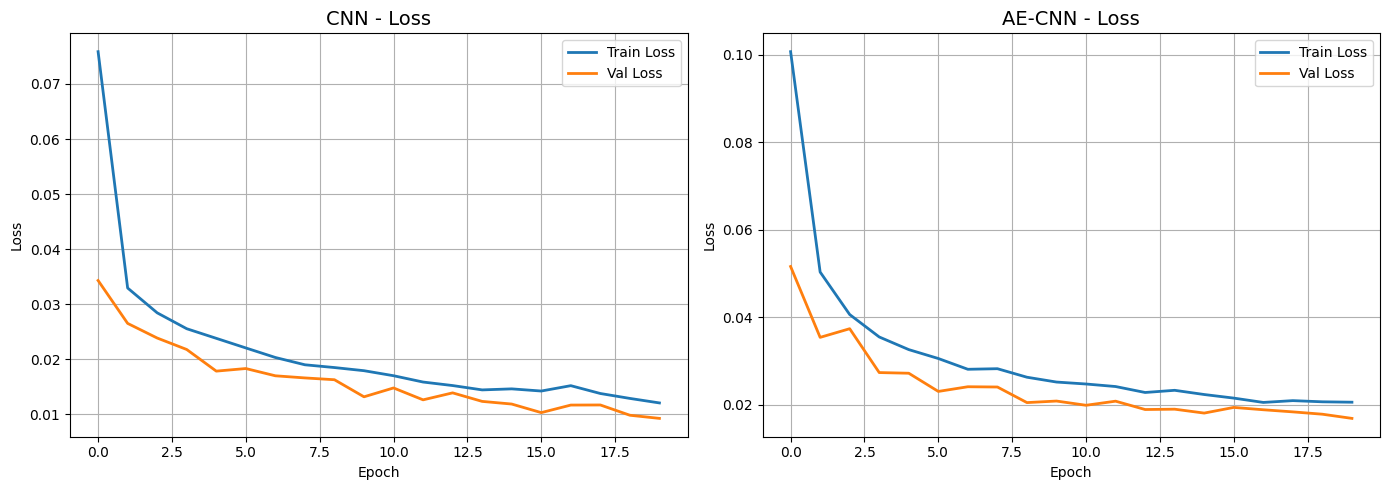

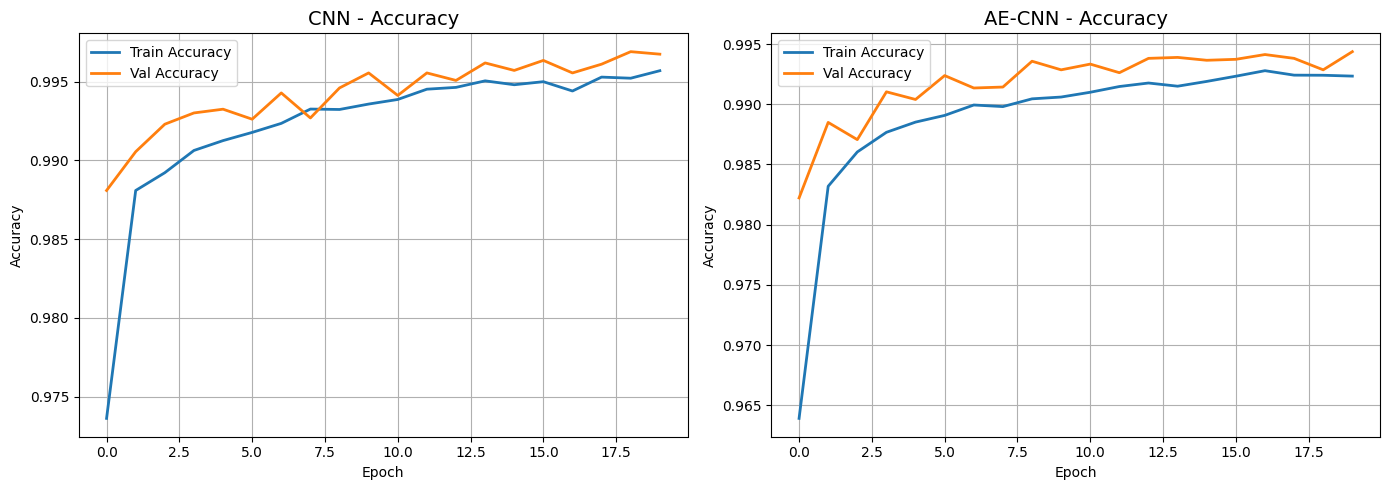


 KARŞILAŞTIRMA TABLOSU
        Accuracy  Precision  Recall  F1-Score
Model                                        
CNN       0.7488     0.9297  0.6045    0.7326
AE-CNN    0.7740     0.9718  0.6211    0.7578


In [8]:
#TAHMİNLER
y_pred_cnn     = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)
y_pred_ae_cnn  = (ae_cnn_model.predict(X_test_ae_cnn) > 0.5).astype(int)

#METRİKLER
print("=" * 50)
print("         CNN MODEL SONUÇLARI")
print("=" * 50)
print(classification_report(y_test, y_pred_cnn, target_names=['Normal', 'Saldırı']))

print("=" * 50)
print("       AE-CNN MODEL SONUÇLARI")
print("=" * 50)
print(classification_report(y_test, y_pred_ae_cnn, target_names=['Normal', 'Saldırı']))

#CONFUSION MATRIX
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_cnn, y_pred_ae_cnn],
                              ['CNN', 'AE-CNN']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Saldırı'],
                yticklabels=['Normal', 'Saldırı'])
    ax.set_title(f'{title} Confusion Matrix', fontsize=14)
    ax.set_ylabel('Gerçek')
    ax.set_xlabel('Tahmin')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

#LOSS GRAFİKLERİ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, title in zip(axes,
                               [cnn_history, ae_cnn_history],
                               ['CNN', 'AE-CNN']):
    ax.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax.set_title(f'{title} - Loss', fontsize=14)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('loss_graphs.png', dpi=150)
plt.show()

#ACCURACY GRAFİKLERİ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, title in zip(axes,
                               [cnn_history, ae_cnn_history],
                               ['CNN', 'AE-CNN']):
    ax.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax.set_title(f'{title} - Accuracy', fontsize=14)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('accuracy_graphs.png', dpi=150)
plt.show()

#KARŞILAŞTIRMA TABLOSU
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Model':     ['CNN', 'AE-CNN'],
    'Accuracy':  [accuracy_score(y_test, y_pred_cnn),
                  accuracy_score(y_test, y_pred_ae_cnn)],
    'Precision': [precision_score(y_test, y_pred_cnn),
                  precision_score(y_test, y_pred_ae_cnn)],
    'Recall':    [recall_score(y_test, y_pred_cnn),
                  recall_score(y_test, y_pred_ae_cnn)],
    'F1-Score':  [f1_score(y_test, y_pred_cnn),
                  f1_score(y_test, y_pred_ae_cnn)]
}

results_df = pd.DataFrame(results).set_index('Model')
print("\n KARŞILAŞTIRMA TABLOSU")
print(results_df.round(4))